# Data Pipeline Monitor Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/pipeline-monitor-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/pipeline-monitor-agent/demo.ipynb)

An agent that watches pipeline run history for failures, slow runs, row-count drops, and **silent staleness** — the case where a job stops running and nobody notices until a user complains.

**What this notebook covers:**
1. The four failure modes this agent catches
2. Running it on a sample pipeline run history
3. Visualizing run durations against the anomaly threshold
4. A "Try Your Own" section for your own pipeline logs


## Step 1: Four ways a pipeline fails quietly

1. **Explicit failure** — job status is `failed`
2. **Slow run** — duration over 2x the job's own historical median
3. **Row-count drop** — rows processed under half the historical median (partial extract)
4. **Staleness** — job hasn't had a successful run in 2x its expected interval (the "nobody noticed it stopped running" case)

Each run is checked against **its own job's history**, so thresholds adapt per job instead of using one global rule.


In [1]:
from __future__ import annotations

import statistics
from dataclasses import dataclass
from datetime import datetime, timedelta
from typing import List, Optional


@dataclass
class PipelineRun:
    job_name: str
    status: str
    start_time: datetime
    duration_seconds: float
    rows_processed: Optional[int] = None
    expected_interval_minutes: int = 60


@dataclass
class Alert:
    job_name: str
    severity: str
    reason: str
    recommended_action: str
    run_time: datetime


def _median(values):
    return statistics.median(values) if values else 0.0


def _rule_based_action(reason: str) -> str:
    lowered = reason.lower()
    if "failed at" in lowered:
        return "check job logs for stack trace, re-run after fixing root cause"
    if "median of" in lowered and "took" in lowered:
        return "check upstream data volume and warehouse load, consider scaling compute"
    if "hasn't succeeded" in lowered or "no recorded successful run" in lowered:
        return "check scheduler/orchestrator, confirm job wasn't silently disabled or stuck"
    if "under half" in lowered:
        return "check upstream source for partial data or an empty extract"
    return "investigate manually"


def check_run(run: PipelineRun, history: List[PipelineRun]) -> Optional[Alert]:
    job_history = [r for r in history if r.job_name == run.job_name and r.start_time < run.start_time]

    if run.status == "failed":
        reason = f"job '{run.job_name}' failed at {run.start_time.isoformat()}"
        severity = "critical"
    elif job_history:
        durations = [r.duration_seconds for r in job_history if r.status == "success"]
        median_duration = _median(durations)
        if median_duration and run.duration_seconds > median_duration * 2:
            reason = f"job '{run.job_name}' took {run.duration_seconds:.0f}s, over 2x the historical median of {median_duration:.0f}s"
            severity = "warning"
        elif run.rows_processed is not None:
            row_counts = [r.rows_processed for r in job_history if r.rows_processed is not None]
            median_rows = _median(row_counts) if row_counts else None
            if median_rows and run.rows_processed < median_rows * 0.5:
                reason = f"job '{run.job_name}' processed {run.rows_processed} rows, under half the historical median of {median_rows:.0f}"
                severity = "warning"
            else:
                return None
        else:
            return None
    else:
        return None

    return Alert(job_name=run.job_name, severity=severity, reason=reason, recommended_action=_rule_based_action(reason), run_time=run.start_time)


def check_staleness(job_name, last_success, expected_interval_minutes, now=None) -> Optional[Alert]:
    now = now or datetime.now()
    if last_success is None:
        reason = f"job '{job_name}' has no recorded successful run"
        severity = "critical"
    elif now - last_success > timedelta(minutes=expected_interval_minutes * 2):
        overdue_minutes = (now - last_success).total_seconds() / 60
        reason = f"job '{job_name}' hasn't succeeded in {overdue_minutes:.0f} min, expected every {expected_interval_minutes} min"
        severity = "critical"
    else:
        return None
    return Alert(job_name=job_name, severity=severity, reason=reason, recommended_action=_rule_based_action(reason), run_time=now)


def monitor_runs(runs: List[PipelineRun], now=None) -> List[Alert]:
    runs_sorted = sorted(runs, key=lambda r: r.start_time)
    alerts: List[Alert] = []
    for i, run in enumerate(runs_sorted):
        alert = check_run(run, runs_sorted[:i])
        if alert:
            alerts.append(alert)
    for job_name in {r.job_name for r in runs}:
        job_runs = [r for r in runs_sorted if r.job_name == job_name]
        successes = [r for r in job_runs if r.status == "success"]
        last_success = max((r.start_time for r in successes), default=None)
        interval = job_runs[-1].expected_interval_minutes if job_runs else 60
        stale_alert = check_staleness(job_name, last_success, interval, now=now)
        if stale_alert:
            alerts.append(stale_alert)
    severity_order = {"critical": 0, "warning": 1, "info": 2}
    return sorted(alerts, key=lambda a: (severity_order[a.severity], a.run_time))

print("Monitor agent loaded.")

Monitor agent loaded.


## Step 2: Build a sample pipeline run history

Three jobs: one with a slow-run anomaly, one that failed and stopped running (silent staleness), one perfectly healthy.


In [2]:
base = datetime(2026, 7, 5, 8, 0)
runs = []

# etl_orders: healthy history, then one slow run
for i in range(6):
    runs.append(PipelineRun("etl_orders", "success", base - timedelta(hours=(6 - i)), duration_seconds=120 + i * 2, rows_processed=10000 + i * 15, expected_interval_minutes=60))
runs.append(PipelineRun("etl_orders", "success", base, duration_seconds=410, rows_processed=9600, expected_interval_minutes=60))

# etl_users: healthy, then fails and never runs again (staleness)
for i in range(3):
    runs.append(PipelineRun("etl_users", "success", base - timedelta(hours=(6 - i) * 2), duration_seconds=60, rows_processed=500, expected_interval_minutes=120))
runs.append(PipelineRun("etl_users", "failed", base - timedelta(hours=1), duration_seconds=15, expected_interval_minutes=120))

# etl_inventory: single healthy run, no issues
runs.append(PipelineRun("etl_inventory", "success", base - timedelta(hours=10), duration_seconds=90, rows_processed=2000, expected_interval_minutes=60))

now = base + timedelta(hours=2, minutes=30)
alerts = monitor_runs(runs, now=now)

for a in alerts:
    print(f"[{a.severity.upper():8s}] {a.job_name:15s} {a.reason}")
    print(f"           -> {a.recommended_action}\n")

[CRITICAL] etl_users       job 'etl_users' failed at 2026-07-05T07:00:00
           -> check job logs for stack trace, re-run after fixing root cause

[CRITICAL] etl_inventory   job 'etl_inventory' hasn't succeeded in 750 min, expected every 60 min
           -> check scheduler/orchestrator, confirm job wasn't silently disabled or stuck

[CRITICAL] etl_users       job 'etl_users' hasn't succeeded in 630 min, expected every 120 min
           -> check scheduler/orchestrator, confirm job wasn't silently disabled or stuck

[CRITICAL] etl_orders      job 'etl_orders' hasn't succeeded in 150 min, expected every 60 min
           -> check scheduler/orchestrator, confirm job wasn't silently disabled or stuck

[WARNING ] etl_orders      job 'etl_orders' took 410s, over 2x the historical median of 125s
           -> check upstream data volume and warehouse load, consider scaling compute



## Visualization: run durations vs anomaly threshold

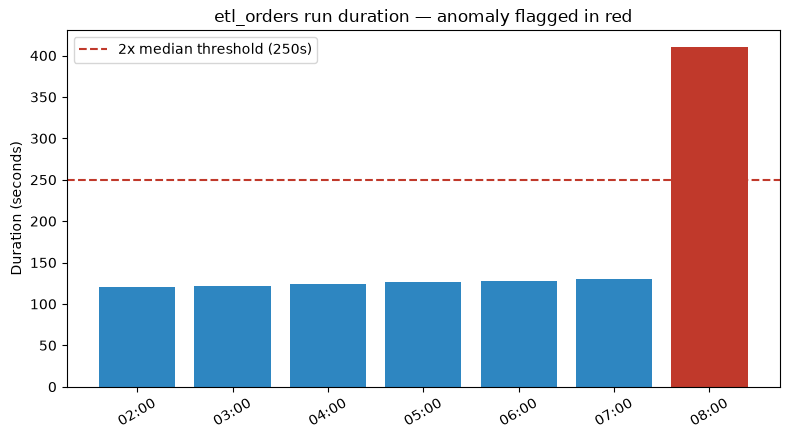

In [3]:
import matplotlib.pyplot as plt
import statistics as stats

orders_runs = sorted([r for r in runs if r.job_name == "etl_orders"], key=lambda r: r.start_time)
durations = [r.duration_seconds for r in orders_runs]
median_duration = stats.median(durations[:-1])  # baseline excludes the anomaly point

fig, ax = plt.subplots(figsize=(8, 4.5))
times = [r.start_time.strftime("%H:%M") for r in orders_runs]
colors = ["#C0392B" if d > median_duration * 2 else "#2E86C1" for d in durations]
ax.bar(times, durations, color=colors)
ax.axhline(median_duration * 2, color="#C0392B", linestyle="--", label=f"2x median threshold ({median_duration * 2:.0f}s)")
ax.set_ylabel("Duration (seconds)")
ax.set_title("etl_orders run duration — anomaly flagged in red")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("run_duration_anomaly.png", dpi=150)
plt.show()

## Summary

The agent caught all three failure modes in this sample: `etl_users` failing and going silent, and
`etl_orders` running 3x slower than usual. `etl_inventory` had no alert since a single successful
run within its interval is healthy. This is the difference between finding out from an angry user
and finding out from a dashboard.


## Try Your Own

Uncomment and adapt to monitor your own pipeline run log:

In [4]:
# my_runs = [
#     PipelineRun("my_job", "success", datetime(2026, 7, 5, 6, 0), duration_seconds=100, rows_processed=5000, expected_interval_minutes=60),
#     PipelineRun("my_job", "failed", datetime(2026, 7, 5, 7, 0), duration_seconds=20, expected_interval_minutes=60),
# ]
# my_alerts = monitor_runs(my_runs, now=datetime(2026, 7, 5, 9, 30))
# for a in my_alerts:
#     print(a.severity, a.job_name, a.reason, a.recommended_action)

---
**[← Back to portfolio](../../README.md)**

For the interactive version with a UI and CSV upload:
```bash
pip install -r requirements.txt
streamlit run app.py
```
Set `ANTHROPIC_API_KEY` for Claude-written recommended actions instead of the rule-based defaults.
